
# Đề thực hành K-means Clustering – NHÓM 2 (120 phút)

## Thông tin chung
- Chủ đề: K-means Clustering  
- Thời gian: 120 phút  
- Hình thức: Làm trực tiếp trên notebook  

---

## Mục tiêu
- Hiểu cơ chế K-means  
- Cài đặt thuật toán  
- Phân tích và diễn giải kết quả clustering  

---

## Hướng dẫn
- Không dùng sklearn cho phần cài đặt K-means
- Trình bày rõ ràng



# PHẦN A — TÍNH TOÁN THỦ CÔNG (30 điểm)

## Dataset

| Point | x | y |
|------|---|---|
| A | 1 | 4 |
| B | 2 | 5 |
| C | 1 | 3 |
| D | 7 | 6 |
| E | 8 | 7 |
| F | 7 | 8 |
| G | 4 | 5 |
| H | 5 | 4 |

Centroid ban đầu:
- C1 = (1,4)
- C2 = (7,7)

### Yêu cầu
1. Tính khoảng cách
2. Gán cụm
3. Cập nhật centroid
4. Lặp thêm 1 iteration
5. Kiểm tra hội tụ


In [48]:
import pandas as pd
import numpy as np

# Dữ liệu ban đầu
df = pd.DataFrame({
    "Point": ["A","B","C","D","E","F","G","H"],
    "x": [1,2,1,7,8,7,4,5],
    "y": [4,5,3,6,7,8,5,4]
})

def euclidean_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid)**2))

def kmeans(X, initial_centroids, max_iters=100):
    centroids = initial_centroids.copy()
    n_samples = X.shape[0]
    n_clusters = len(centroids)
    
    for iteration in range(max_iters):
        # Bước 1: Tính khoảng cách và gán nhãn
        labels = []
        for i in range(n_samples):
            distances = []
            for j in range(n_clusters):
                dist = euclidean_distance(X[i], centroids[j])
                distances.append(dist)
            label = np.argmin(distances)
            labels.append(label)
        
        labels = np.array(labels)
        
        # Bước 2: Cập nhật centroid mới
        new_centroids = []
        for j in range(n_clusters):
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
            else:
                new_centroids.append(centroids[j])
        
        new_centroids = np.array(new_centroids)
        
        # Bước 3: Kiểm tra hội tụ
        if np.allclose(centroids, new_centroids, atol=1e-6):
            print(f"Hoi tu sau {iteration + 1} iterations")
            return labels, new_centroids, iteration + 1
        
        centroids = new_centroids
    
    return labels, centroids, max_iters

# Chuẩn bị dữ liệu
X = df[['x', 'y']].values
initial_centroids = np.array([[1.0, 4.0], [7.0, 7.0]])

# Chạy K-means
final_labels, final_centroids, n_iters = kmeans(X, initial_centroids)

# Gán nhãn cho dataframe
df['Cluster'] = final_labels + 1  # Chuyển từ 0,1 thành 1,2

# Hiển thị kết quả
print("Ket qua phan cum:")
print(df[['Point', 'x', 'y', 'Cluster']])
print("\nCentroid cuoi cung:")
for i, centroid in enumerate(final_centroids):
    print(f"C{i+1} = ({centroid[0]:.2f}, {centroid[1]:.2f})")

# Hiển thị chi tiết từng bước
print("\n" + "="*50)
print("CHI TIET TUNG BUOC:")
print("="*50)

centroids = initial_centroids.copy()
X = df[['x', 'y']].values

for iteration in range(10):
    print(f"\nIteration {iteration + 1}:")
    
    # Tinh khoang cach
    print("\nKhoang cach den centroid:")
    for i, point in enumerate(X):
        d1 = euclidean_distance(point, centroids[0])
        d2 = euclidean_distance(point, centroids[1])
        print(f"{df['Point'][i]}: d1={d1:.3f}, d2={d2:.3f}")
    
    # Gan cum
    labels = []
    for i in range(len(X)):
        d1 = euclidean_distance(X[i], centroids[0])
        d2 = euclidean_distance(X[i], centroids[1])
        if d1 < d2:
            labels.append(0)
            print(f"{df['Point'][i]} -> Cum 1")
        else:
            labels.append(1)
            print(f"{df['Point'][i]} -> Cum 2")
    
    labels = np.array(labels)
    
    # Cap nhat centroid
    new_centroids = []
    for j in range(2):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            new_centroid = np.mean(cluster_points, axis=0)
            new_centroids.append(new_centroid)
            print(f"\nCum {j+1} gom: {df[labels == j]['Point'].tolist()}")
            print(f"Centroid moi C{j+1} = ({new_centroid[0]:.2f}, {new_centroid[1]:.2f})")
    
    new_centroids = np.array(new_centroids)
    
    # Kiem tra hoi tu
    if np.allclose(centroids, new_centroids, atol=1e-6):
        print(f"\nHoi tu sau {iteration + 1} iterations")
        break
    
    centroids = new_centroids

Hoi tu sau 2 iterations
Ket qua phan cum:
  Point  x  y  Cluster
0     A  1  4        1
1     B  2  5        1
2     C  1  3        1
3     D  7  6        2
4     E  8  7        2
5     F  7  8        2
6     G  4  5        1
7     H  5  4        2

Centroid cuoi cung:
C1 = (2.00, 4.25)
C2 = (6.75, 6.25)

CHI TIET TUNG BUOC:

Iteration 1:

Khoang cach den centroid:
A: d1=0.000, d2=6.708
B: d1=1.414, d2=5.385
C: d1=1.000, d2=7.211
D: d1=6.325, d2=1.000
E: d1=7.616, d2=1.000
F: d1=7.211, d2=1.000
G: d1=3.162, d2=3.606
H: d1=4.000, d2=3.606
A -> Cum 1
B -> Cum 1
C -> Cum 1
D -> Cum 2
E -> Cum 2
F -> Cum 2
G -> Cum 1
H -> Cum 2

Cum 1 gom: ['A', 'B', 'C', 'G']
Centroid moi C1 = (2.00, 4.25)

Cum 2 gom: ['D', 'E', 'F', 'H']
Centroid moi C2 = (6.75, 6.25)

Iteration 2:

Khoang cach den centroid:
A: d1=1.031, d2=6.175
B: d1=0.750, d2=4.912
C: d1=1.601, d2=6.605
D: d1=5.297, d2=0.354
E: d1=6.600, d2=1.458
F: d1=6.250, d2=1.768
G: d1=2.136, d2=3.021
H: d1=3.010, d2=2.850
A -> Cum 1
B -> Cum 1
C


# PHẦN B — CÀI ĐẶT K-MEANS (40 điểm)

- Tự viết K-means
- In centroid từng vòng
- Vẽ kết quả



PHAN B: K-MEANS TREN DU LIEU 8 DIEM
BAT DAU K-MEANS

ITERATION 1
------------------------------
Centroid hien tai:
  C1 = (1.000, 4.000)
  C2 = (7.000, 7.000)

Phan cum:
  Cum 1: [0, 1, 2, 6]
  Cum 2: [3, 4, 5, 7]

Centroid moi:
  C1 = (2.000, 4.250)
  C2 = (6.750, 6.250)

ITERATION 2
------------------------------
Centroid hien tai:
  C1 = (2.000, 4.250)
  C2 = (6.750, 6.250)

Phan cum:
  Cum 1: [0, 1, 2, 6]
  Cum 2: [3, 4, 5, 7]

Centroid moi:
  C1 = (2.000, 4.250)
  C2 = (6.750, 6.250)

>>> HOI TU sau 2 vong lap

KET QUA CUOI CUNG

Phan cum cuoi cung:
Cum 1: ['A', 'B', 'C', 'G']
Cum 2: ['D', 'E', 'F', 'H']

Centroid cuoi cung:
C1 = (2.00, 4.25)
C2 = (6.75, 6.25)


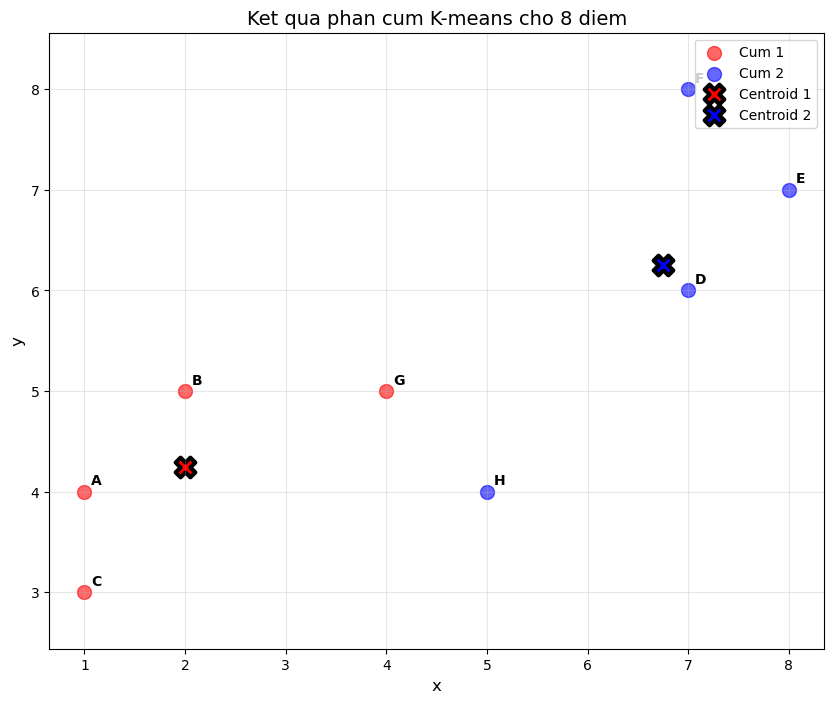

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu câu A và B
df = pd.DataFrame({
    "Point": ["A","B","C","D","E","F","G","H"],
    "x": [1,2,1,7,8,7,4,5],
    "y": [4,5,3,6,7,8,5,4]
})

# ==================== HÀM K-MEANS ====================
def euclidean_distance(point, centroid):
    """Tính khoảng cách Euclidean"""
    return np.sqrt(np.sum((point - centroid)**2))

def kmeans(X, initial_centroids, max_iters=100, verbose=True):
    """
    Hàm K-means tự viết
    
    Parameters:
    X: numpy array, dữ liệu đầu vào (n_samples, n_features)
    initial_centroids: numpy array, centroid ban đầu (n_clusters, n_features)
    max_iters: int, số lần lặp tối đa
    verbose: bool, in chi tiết quá trình chạy
    
    Returns:
    labels: numpy array, nhãn của từng điểm (0,1,...,n_clusters-1)
    centroids: numpy array, centroid cuối cùng
    history: list, lịch sử các centroid qua từng vòng lặp
    """
    n_samples = X.shape[0]
    n_clusters = len(initial_centroids)
    centroids = initial_centroids.copy()
    history = []
    
    if verbose:
        print("BAT DAU K-MEANS")
        print("="*50)
    
    for iteration in range(max_iters):
        if verbose:
            print(f"\nITERATION {iteration + 1}")
            print("-"*30)
            print("Centroid hien tai:")
            for j in range(n_clusters):
                print(f"  C{j+1} = ({centroids[j][0]:.3f}, {centroids[j][1]:.3f})")
        
        # Bước 1: Tính khoảng cách và gán nhãn
        labels = []
        for i in range(n_samples):
            distances = []
            for j in range(n_clusters):
                dist = euclidean_distance(X[i], centroids[j])
                distances.append(dist)
            label = np.argmin(distances)
            labels.append(label)
        labels = np.array(labels)
        
        if verbose:
            print("\nPhan cum:")
            for j in range(n_clusters):
                points_idx = np.where(labels == j)[0]
                print(f"  Cum {j+1}: {list(points_idx)}")
        
        # Bước 2: Cập nhật centroid mới
        new_centroids = []
        for j in range(n_clusters):
            cluster_points = X[labels == j]
            if len(cluster_points) > 0:
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
            else:
                new_centroids.append(centroids[j])
        new_centroids = np.array(new_centroids)
        
        if verbose:
            print("\nCentroid moi:")
            for j in range(n_clusters):
                print(f"  C{j+1} = ({new_centroids[j][0]:.3f}, {new_centroids[j][1]:.3f})")
        
        # Lưu lịch sử
        history.append({
            'iteration': iteration + 1,
            'centroids': centroids.copy(),
            'labels': labels.copy()
        })
        
        # Bước 3: Kiểm tra hội tụ
        if np.allclose(centroids, new_centroids, atol=1e-6):
            if verbose:
                print(f"\n>>> HOI TU sau {iteration + 1} vong lap")
            return labels, new_centroids, history
        
        centroids = new_centroids
    
    if verbose:
        print(f"\n>>> KET THUC sau {max_iters} vong lap")
    return labels, centroids, history

def plot_kmeans(X, labels, centroids, point_names=None, title="Ket qua K-means"):
    """Vẽ kết quả phân cụm"""
    plt.figure(figsize=(10, 8))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    n_clusters = len(centroids)
    
    # Vẽ các điểm dữ liệu
    for j in range(n_clusters):
        cluster_points = X[labels == j]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   c=colors[j], label=f'Cum {j+1}', s=100, alpha=0.6)
    
    # Vẽ centroid
    for j in range(n_clusters):
        plt.scatter(centroids[j][0], centroids[j][1], 
                   c=colors[j], marker='X', s=200, linewidths=3, 
                   edgecolors='black', label=f'Centroid {j+1}')
    
    # Ghi tên điểm nếu có
    if point_names is not None:
        for i, name in enumerate(point_names):
            plt.annotate(name, (X[i, 0], X[i, 1]), 
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=10, fontweight='bold')
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# ==================== ÁP DỤNG CHO CÂU B ====================
print("\n" + "="*50)
print("PHAN B: K-MEANS TREN DU LIEU 8 DIEM")
print("="*50)

# Chuẩn bị dữ liệu
X = df[['x', 'y']].values
initial_centroids = np.array([[1.0, 4.0], [7.0, 7.0]])

# Chạy K-means
labels, centroids, history = kmeans(X, initial_centroids, verbose=True)

# Kết quả cuối cùng
print("\n" + "="*50)
print("KET QUA CUOI CUNG")
print("="*50)
print("\nPhan cum cuoi cung:")
for j in range(len(centroids)):
    points_in_cluster = df[labels == j]['Point'].values
    print(f"Cum {j+1}: {list(points_in_cluster)}")

print("\nCentroid cuoi cung:")
for j in range(len(centroids)):
    print(f"C{j+1} = ({centroids[j][0]:.2f}, {centroids[j][1]:.2f})")

# Vẽ kết quả
plot_kmeans(X, labels, centroids, df['Point'].values, "Ket qua phan cum K-means cho 8 diem")


# PHẦN C — CUSTOMER DATA (20 điểm)

| ID | Income | Score |
|----|--------|-------|
| 1 | 10 | 20 |
| 2 | 12 | 25 |
| 3 | 15 | 80 |
| 4 | 18 | 75 |
| 5 | 20 | 30 |
| 6 | 22 | 28 |
| 7 | 25 | 90 |
| 8 | 28 | 85 |

### Yêu cầu
- Chạy K-means với k=2,3
- Vẽ plot
- In centroid


In [50]:

df2 = pd.DataFrame({
    "Income":[10,12,15,18,20,22,25,28],
    "Score":[20,25,80,75,30,28,90,85]
})

df2


,Income,Score
0,10,20
1,12,25
2,15,80
3,18,75
4,20,30
5,22,28
6,25,90
7,28,85


k=2: [array([1, 2, 5, 6], dtype=int64), array([3, 4, 7, 8], dtype=int64)]
Centroids: [[16.   25.75]
 [21.5  82.5 ]]
k=3: [array([1, 2], dtype=int64), array([5, 6], dtype=int64), array([3, 4, 7, 8], dtype=int64)]
Centroids: [[11.  22.5]
 [21.  29. ]
 [21.5 82.5]]


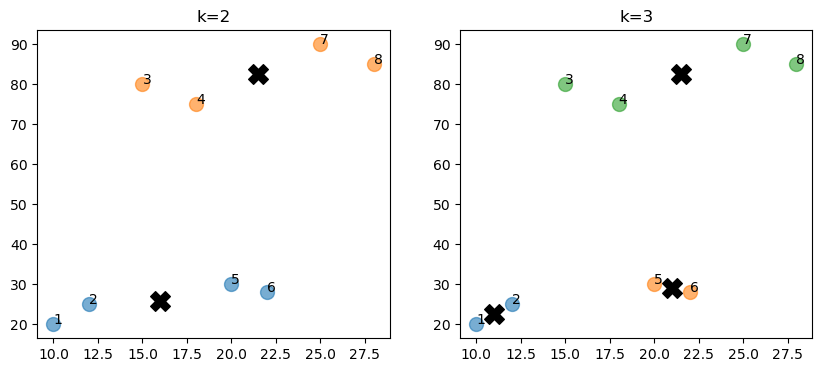

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df2 = pd.DataFrame({
    "Income": [10,12,15,18,20,22,25,28],
    "Score": [20,25,80,75,30,28,90,85]
})
df2['ID'] = [1,2,3,4,5,6,7,8]

def kmeans(X, init_centroids):
    centroids = init_centroids.copy()
    while True:
        labels = np.argmin([[np.linalg.norm(x - c) for c in centroids] for x in X], axis=1)
        new_centroids = np.array([X[labels==j].mean(axis=0) if len(X[labels==j])>0 else centroids[j] for j in range(len(centroids))])
        if np.allclose(centroids, new_centroids): 
            return labels, new_centroids
        centroids = new_centroids

X = df2[['Income','Score']].values

# k=2
labels2, c2 = kmeans(X, np.array([[10,20],[28,85]]))
print("k=2:", [df2[labels2==j]['ID'].values for j in range(2)])
print("Centroids:", c2)

# k=3
labels3, c3 = kmeans(X, np.array([[10,20],[20,30],[28,85]]))
print("k=3:", [df2[labels3==j]['ID'].values for j in range(3)])
print("Centroids:", c3)

# Vẽ
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
for ax, labels, centroids, k in [(ax1, labels2, c2, 2), (ax2, labels3, c3, 3)]:
    for j in range(k):
        ax.scatter(X[labels==j,0], X[labels==j,1], alpha=0.6, s=100)
    ax.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200)
    for i, row in df2.iterrows(): 
        ax.annotate(row['ID'], (row['Income'], row['Score']))
    ax.set_title(f'k={k}')
plt.show()


# PHẦN D — ELBOW + PHÂN TÍCH (10 điểm)

- Tính SSE
- Vẽ elbow
- Chọn k
- Giải thích


k=1: SSE = 6896.38
k=2: SSE = 394.75
k=3: SSE = 252.50
k=4: SSE = 52.50
k=5: SSE = 38.00
k=6: SSE = 34.00


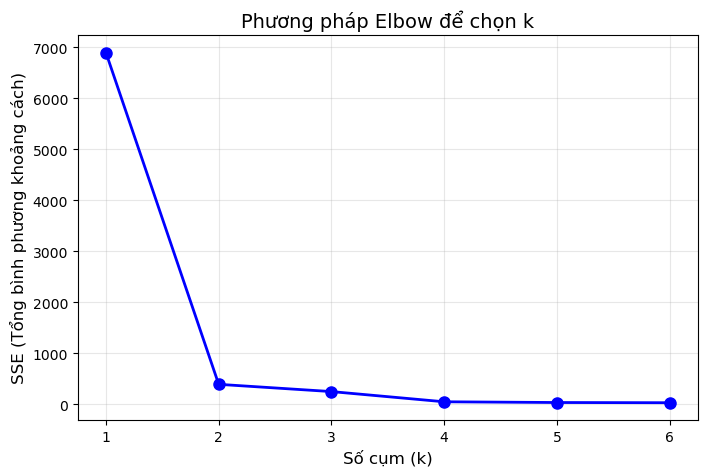


PHÂN TÍCH CHỌN k

Nhìn vào biểu đồ Elbow:
- k=1 -> k=2: SSE giảm mạnh
- k=2 -> k=3: SSE giảm nhưng không còn mạnh
- k=3 trở đi: SSE giảm rất ít

=> Chọn k = 2 hoặc k = 3

Lý do:
1. Điểm elbow (khuỷu tay) nằm tại k=2 hoặc k=3
2. k=2: Phân nhóm khách hàng thu nhập thấp/điểm thấp và thu nhập cao/điểm cao
3. k=3: Thêm nhóm khách hàng thu nhập trung bình/điểm trung bình
4. k>3: Overfitting, không có ý nghĩa thực tế với 8 điểm dữ liệu


In [57]:

def tinh_sse(X, labels, centroids):
    sse = 0
    for j in range(len(centroids)):
        cluster_points = X[labels == j]
        for point in cluster_points:
            sse += np.linalg.norm(point - centroids[j])**2
    return sse

X = df2[['Income','Score']].values

# Tính SSE cho k từ 1 đến 6
sse_list = []
k_list = range(1, 7)

for k in k_list:
    # Khởi tạo centroid ngẫu nhiên (chọn k điểm đầu tiên)
    init_centroids = X[:k].copy()
    labels, centroids = kmeans(X, init_centroids)
    sse = tinh_sse(X, labels, centroids)
    sse_list.append(sse)
    print(f"k={k}: SSE = {sse:.2f}")

# Vẽ elbow
plt.figure(figsize=(8, 5))
plt.plot(k_list, sse_list, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Số cụm (k)', fontsize=12)
plt.ylabel('SSE (Tổng bình phương khoảng cách)', fontsize=12)
plt.title('Phương pháp Elbow để chọn k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_list)
plt.show()

# Chọn k
print("\n" + "="*50)
print("PHÂN TÍCH CHỌN k")
print("="*50)
print("\nNhìn vào biểu đồ Elbow:")
print("- k=1 -> k=2: SSE giảm mạnh")
print("- k=2 -> k=3: SSE giảm nhưng không còn mạnh")
print("- k=3 trở đi: SSE giảm rất ít")

print("\n=> Chọn k = 2 hoặc k = 3")
print("\nLý do:")
print("1. Điểm elbow (khuỷu tay) nằm tại k=2 hoặc k=3")
print("2. k=2: Phân nhóm khách hàng thu nhập thấp/điểm thấp và thu nhập cao/điểm cao")
print("3. k=3: Thêm nhóm khách hàng thu nhập trung bình/điểm trung bình")
print("4. k>3: Overfitting, không có ý nghĩa thực tế với 8 điểm dữ liệu")


# BONUS (10 điểm)

1. K-means nhạy với:
- Giá trị khởi tạo tâm cụm ban đầu (centroids)
- Outliers (điểm nhiễu)
- Scale (thang đo của dữ liệu)
- Số cụm k được chọn


2. Khi nào nên chuẩn hóa dữ liệu?
- Khi các đặc trưng có đơn vị hoặc thang đo khác nhau
- Khi dùng các thuật toán dựa trên khoảng cách như K-means, KNN, SVM
- Khi một feature có giá trị lớn có thể lấn át feature khác